Import `quick` modules. For this demo, we will import the circuit instances.

In [2]:
from quick.circuit import QiskitCircuit, Ansatz
from quick.circuit.circuit_utils import flatten, reshape

We will also import some basic modules for angle calculations.

In [3]:
import numpy as np

### Variational Quantum Computing

Quantum Circuits with single qubit rotation gates are known as Parameterized Quantum Circuits (PQC). If we variationally update the rotation angles of a PQC to minimize a cost function, we call the PQC an Ansatze for clarity in notation.

In `quick.circuit`, we provide the Ansatze as a separate class for brevity and easier readability. You can use `quick.circuit.Ansatz` to "convert" ordinary `quick.circuit.Circuit` instances to ansatzes. This is done by simply using the `.update()` where we just change the rotation angle values and update to re-construct the updated circuit. Use-cases of variational quantum circuits include:
- Supervised QML
- Approximate Quantum Compilation (AQC)
- Quantum Approximate Optimization Algorithm (QAOA)
- Variational Quantum Eigensolver (VQE)

For this notebook, we will mainly focus on AQC.

We will use `scipy.optimize.minimize` for optimizing the parameters. Scipy provides an elegant and minimalistic interface for accessing a variety of SOTA optimization algorithms without the hassle of manually setting each one up or passing a multitude of hyper-parameters. For our use-case in this notebook, scipy is an excellet fit. It should however be noted that if the use-case requires more sophisticated optimization techniques depending on the cost landscape, users are urged to implement their own optimization routines and/or use more advanced optimization libraries.

In [4]:
from scipy.optimize import minimize

Next, we will generate a random state to be encoded using Shende's synthesis as our initial parameter.

In [5]:
from quick.random import generate_random_state

random_state = generate_random_state(6)

In [6]:
circuit = QiskitCircuit(6)
circuit.initialize(random_state, range(6))

ansatz = Ansatz(circuit)

Next, we will define our target state (the state which we want to prepare). The goal of our VQA is to variationally train the circuit such that the inner-product between the statevector represented by our ansatz and the target state is maximized, or in other words the infidelity is minimized.

We can use any arbitrary statevector, but for visualization purposes let's use a MNIST image instance.

In [7]:
import pandas as pd

# Load in the resized MNIST dataset
dataset = pd.read_csv('datasets/mnist-resized.csv')

# Convert the dataset to a numpy array
images = dataset.to_numpy()[:,1:].reshape(30018, 8, 8)

# Get the first image
test_image = images.reshape(30018, 8, 8)[0, :]

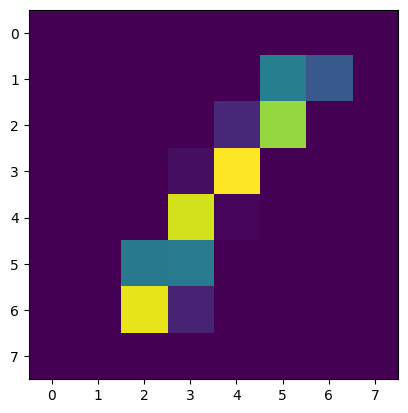

In [8]:
import matplotlib.pyplot as plt

# Plot the first image
plt.imshow(test_image)
plt.show()

In [9]:
target_state = test_image.flatten() / np.linalg.norm(test_image.flatten())

In [10]:
target_state.conj().T @ ansatz.ansatz.get_statevector()

(0.24593246121529486+0.14333213936238834j)

We will then define the training routine and plot the improvements as we optimize. In case the scipy optimizer keeps going after the `max_iter` threshold, feel free to interrupt the cell.

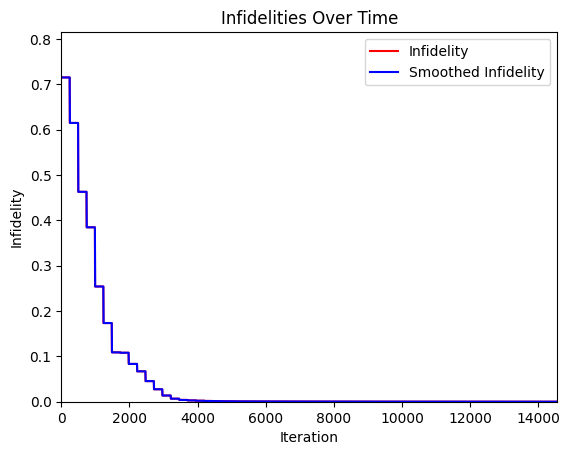

KeyboardInterrupt: 

In [11]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

infidelities = []

def cost_function(thetas, shape) -> complex:
    ansatz.thetas = reshape(thetas, shape)

    infidelity = 1 - abs(target_state.conj().T @ ansatz.ansatz.get_statevector())

    infidelities.append(infidelity)
    update_plot(infidelities)

    return infidelity

# Create a figure and axis for dynamic plotting
fig, ax = plt.subplots()
line, = ax.plot([], [], 'r-', label='Infidelity')
smooth_line, = ax.plot([], [], 'b-', label='Smoothed Infidelity')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Infidelities Over Time')
ax.set_xlabel('Iteration')
ax.set_ylabel('Infidelity')
ax.legend()

# Function to update the plot
def update_plot(new_data):
    line.set_xdata(range(len(new_data)))
    line.set_ydata(new_data)

    # Calculate the moving average
    window_size = 5
    if len(new_data) >= window_size:
        smoothed_data = np.convolve(new_data, np.ones(window_size)/window_size, mode='valid')
        smooth_line.set_xdata(range(window_size-1, len(new_data)))
        smooth_line.set_ydata(smoothed_data)

    ax.set_xlim(0, len(new_data))
    ax.set_ylim(0, max(new_data) + 0.1)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)

# Initial parameters for the ansatz
initial_params, shape = flatten(ansatz.thetas)

# Define bounds for each parameter to be between 0 and 2*pi
bounds = [(0, 2*np.pi) for _ in initial_params]

# Perform the optimization
result = minimize(cost_function, initial_params, args=(shape), method="BFGS", options={'maxiter': 2000})

plt.show()

Note that we performed the training with the absolute of the probability amplitudes as the image encoding does not require the inner product to be specifically 1+0j. For general state preparation, you need to use
```py
def cost_function(thetas, shape) -> complex:
    ansatz.thetas = reshape(thetas, shape)

    infidelity = 1 - target_state.conj().T @ ansatz.ansatz.get_statevector()

    infidelities.append(infidelity)
    update_plot(infidelities)

    return infidelity
```
Which will push the fidelity to be exactly 1+0j. However, note that would limit the good parameter space to a very tiny space, whereas for the absolute approach there are many more possible parameter states to choose from. This is how we reach convergence easier compared to a general state. With that being said, pay close attention to the task and what the cost function really needs to do.

In [12]:
np.inner(target_state.conj().T, ansatz.ansatz.get_statevector())

(0.5896664357293144+0.807564869009721j)

Whilst the inner-product is a fundamental measure of similarity, let us use our own eyes to assess the quality of the approximation.

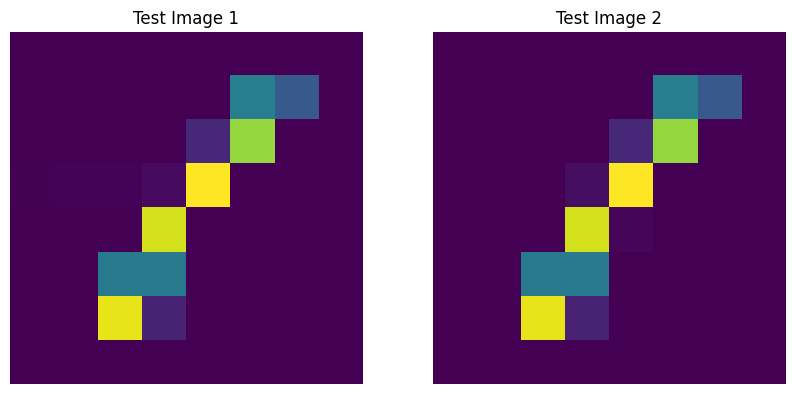

In [13]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first image
axes[0].imshow(abs(ansatz.ansatz.get_statevector()).reshape(8, 8))
axes[0].set_title('Test Image 1')
axes[0].axis('off')

# Plot the second image
axes[1].imshow(test_image)
axes[1].set_title('Test Image 2')
axes[1].axis('off')

# Display the plot
plt.show()

For AQC, we often would use a much smaller ansatz so as to justify the training cost. However, for ease in demonstration and better fidelity we used an exact circuit and simply updated the parameters to what Shende's synthesis would have gotten to.

It should also be noted that when we attempt a global optimization of the circuit like we did here, we are prone to the **"orthogonality catastrophe"**. Orthogonality catastrophe in quantum machine learning refers to a situation where a small change in the parameters of a quantum model causes the quantum state to change drastically, becoming almost completely different (orthogonal) from the original state. This causes an exponential decay in the fidelity measure as the size of the system (number of qubits) increases. That is why for the 6 qubit instance we have 94 fidelity, but for 3 or 4 qubits we can reach 99.999.

This can cause problems during training because:
- **Vanishing Gradients:** The changes in the cost function become very small, making it hard to update the parameters.
- **Optimization Instability:** The training process can become unstable and not converge properly.

In Layman terms, the larger the circuit, the harder it is to train when done globally.

To deal with this, techniques like careful parameter initialization, regularization, and adaptive optimization algorithms are used to make the training process smoother and more stable. We can also trade time to run with better convergence by training a batch of parameters at a time instead of all. This means many more runs of the circuit, but mitigates the orthogonality issue.

<p>© 2025 Qualition Computing, all rights reserved.</p>